In [520]:
# Supress warnings
import warnings
warnings.filterwarnings('ignore')

In [521]:
# Import pandas and numpy packages

import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

### Read and explore the data

In [522]:
data = pd.read_csv('Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Dimensions

In [523]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 545
Columns: 13


General information

In [524]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [525]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


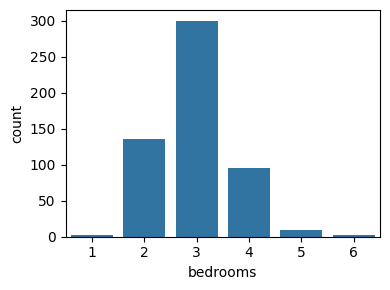

In [526]:
plt.figure(figsize=(4,3))
sns.countplot(data, x='bedrooms')
#sns.kdeplot(data, x='bedrooms', fill=True, color='green')
plt.tight_layout()
plt.show()

In [527]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Identifying possible binary/categorical variables

In [528]:
categoricals = list()
numericals = list()
for column in data.columns:
    print(f"{column}: {data[column].dtypes}")
    if len(data[column].unique()) <= 3:
        categoricals.append(column)
    if data[column].dtypes == 'int64':
        numericals.append(column)
print(f"Categorical columns: {categoricals}")
print(f"Numerical Columns: {numericals}")

price: int64
area: int64
bedrooms: int64
bathrooms: int64
stories: int64
mainroad: object
guestroom: object
basement: object
hotwaterheating: object
airconditioning: object
parking: int64
prefarea: object
furnishingstatus: object
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numerical Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [529]:
# Converting binary variables to category
for categorical in categoricals:
    data[categorical] = data[categorical].astype('category')

In [530]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


Outlier Analysis

In [531]:
numericals

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

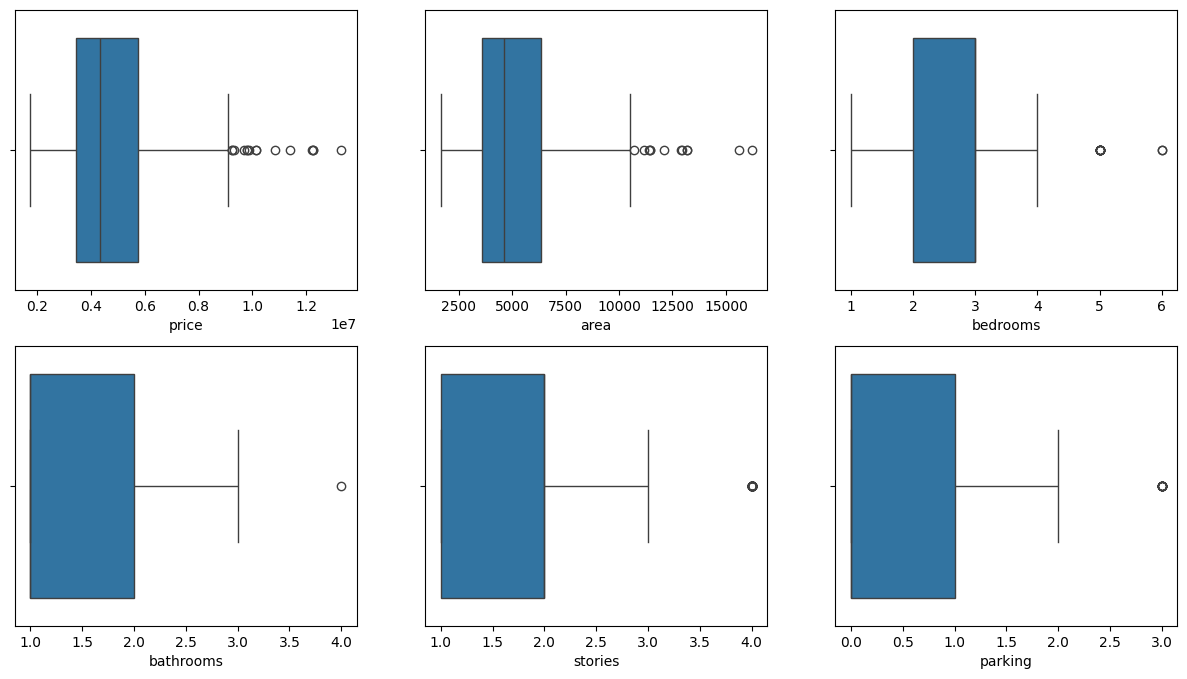

In [532]:
# Visually
plt.figure(figsize=(15, 8))
plt.subplot(2,3,1)
sns.boxplot(data, x='price')
plt.subplot(2,3,2)
sns.boxplot(data, x='area')
plt.subplot(2, 3, 3)
sns.boxplot(data, x='bedrooms')
plt.subplot(2,3,4)
sns.boxplot(data, x='bathrooms')
plt.subplot(2,3,5)
sns.boxplot(data, x='stories')
plt.subplot(2,3,6)
sns.boxplot(data, x='parking')
plt.show()

Outlier treatment for price

In [533]:
q1 = data.price.quantile(0.25)
q3 = data.price.quantile(0.75)
iqr = q3-q1
mean = data.price.mean()
median = data.price.median()
lb = q1 - 1.5*iqr
ub = q3 + 1.5*iqr
outliers = data.loc[~((data.price >= lb) & (data.price <= ub)), 'price'].values
print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Mean price: {mean}")
print(f"Median price: {median}")
print(f"Lower bound: {lb}")
print(f"Upper bound: {ub}")
print(f"Outliers: {outliers}")


Q1: 3430000.0
Q3: 5740000.0
IQR: 2310000.0
Mean price: 4766729.247706422
Median price: 4340000.0
Lower bound: -35000.0
Upper bound: 9205000.0
Outliers: [13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000
  9870000  9800000  9800000  9681000  9310000  9240000  9240000]


In [534]:
# Removing price outliers from data
data = data.loc[((data.price > lb) & (data.price < ub)), :].reset_index(drop=True)

In [535]:
data.shape

(530, 13)

In [536]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.300000e+02,530.000000,530.000000,530.000000,530.000000,530.000000
mean,4.600663e+06,5061.518868,2.943396,1.260377,1.788679,0.664151
std,1.596119e+06,2075.449479,0.730515,0.464359,0.861190,0.843320
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3547.500000,2.000000,1.000000,1.000000,0.000000
50%,4.270000e+06,4500.000000,3.000000,1.000000,2.000000,0.000000
75%,5.600000e+06,6315.750000,3.000000,1.000000,2.000000,1.000000
max,9.100000e+06,15600.000000,6.000000,3.000000,4.000000,3.000000


Outlier treatment for area

In [537]:
q1 = data.area.quantile(0.25)
q3 = data.area.quantile(0.75)
iqr = q3-q1
mean = data.area.mean()
median = data.area.median()
lb = q1-(1.5*iqr)
ub = q3+(1.5*iqr)

outliers = data.loc[~((data.area >= lb) & (data.area <= ub)), 'area'].values

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Lower bound: {lb}")
print(f"Upper bound: {ub}")
print(f"Outliers: {outliers}")

Q1: 3547.5
Q3: 6315.75
IQR: 2768.25
Mean: 5061.518867924528
Median: 4500.0
Lower bound: -604.875
Upper bound: 10468.125
Outliers: [11440 11175 13200 12090 10500 15600 11460 10500 10500 11410 10700 12900
 12944]


In [538]:
# Removing area outliers from data
data = data.loc[((data.area >= lb) & (data.area <= ub)), :].reset_index(drop=True)

In [539]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             517 non-null    int64   
 1   area              517 non-null    int64   
 2   bedrooms          517 non-null    int64   
 3   bathrooms         517 non-null    int64   
 4   stories           517 non-null    int64   
 5   mainroad          517 non-null    category
 6   guestroom         517 non-null    category
 7   basement          517 non-null    category
 8   hotwaterheating   517 non-null    category
 9   airconditioning   517 non-null    category
 10  parking           517 non-null    int64   
 11  prefarea          517 non-null    category
 12  furnishingstatus  517 non-null    category
dtypes: category(7), int64(6)
memory usage: 28.8 KB


### Check multi-collinearity

Numeical Variables

In [540]:
data.loc[:, numericals].corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.533186,0.335328,0.466483,0.446839,0.321058
area,0.533186,1.000000,0.127745,0.171528,0.109877,0.357276
bedrooms,0.335328,0.127745,1.000000,0.346230,0.406684,0.105561
bathrooms,0.466483,0.171528,0.346230,1.000000,0.311314,0.127102
stories,0.446839,0.109877,0.406684,0.311314,1.000000,0.022043
parking,0.321058,0.357276,0.105561,0.127102,0.022043,1.000000


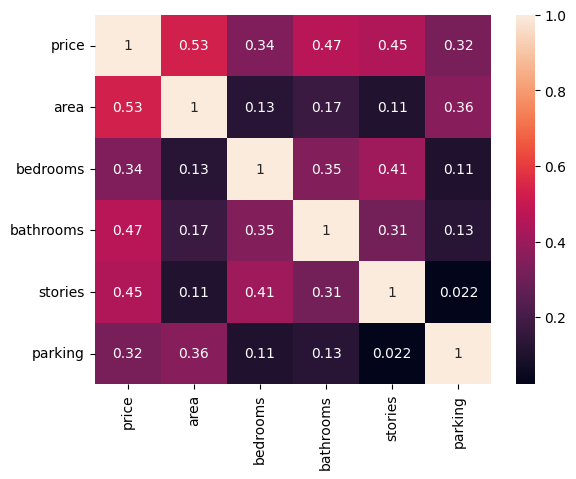

In [541]:
plt.figure()
sns.heatmap(data.loc[:, numericals].corr(), annot=True)
plt.show()

Categorical Variables

In [542]:
categoricals

['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

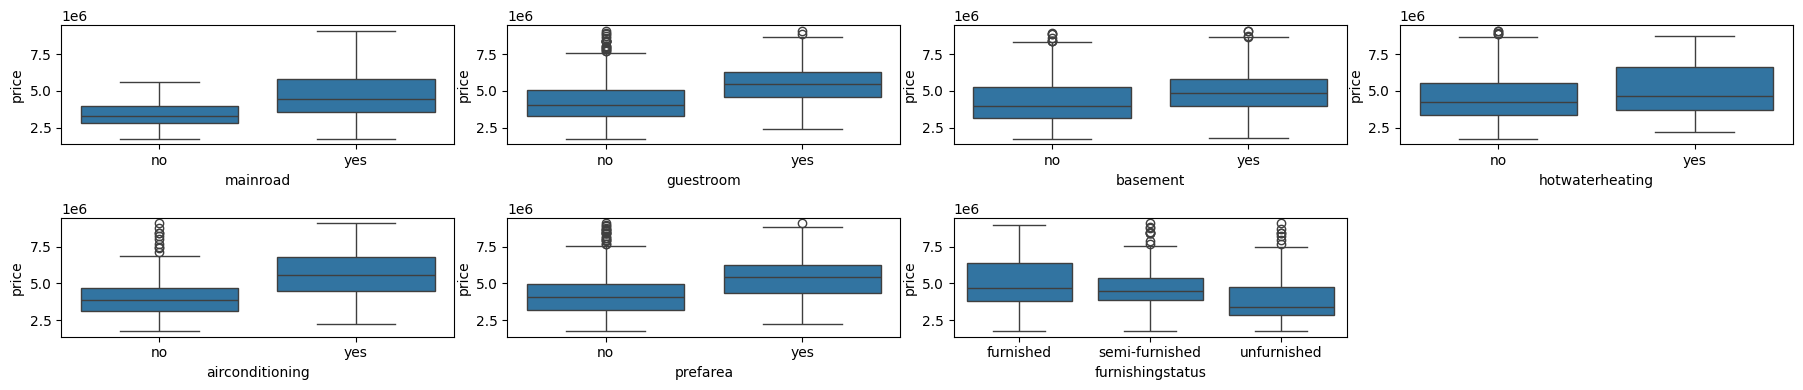

In [543]:
plt.figure(figsize=(18, 4))
plt.subplot(2,4, 1)
sns.boxplot(data, x='mainroad', y='price')
plt.subplot(2,4,2)
sns.boxplot(data, x='guestroom', y='price')
plt.subplot(2,4,3)
sns.boxplot(data, x='basement', y='price')
plt.subplot(2,4,4)
sns.boxplot(data=data, x='hotwaterheating', y='price')
plt.subplot(2,4,5)
sns.boxplot(data=data, x='airconditioning', y='price')
plt.subplot(2,4,6)
sns.boxplot(data=data, x='prefarea', y='price')
plt.subplot(2,4,7)
sns.boxplot(data=data, x='furnishingstatus', y='price')
plt.tight_layout()
plt.show()

### Convert data to features

In [544]:
for categorical in categoricals:
    print(f"{data[categorical].value_counts()}")

mainroad
yes    440
no      77
Name: count, dtype: int64
guestroom
no     425
yes     92
Name: count, dtype: int64
basement
no     338
yes    179
Name: count, dtype: int64
hotwaterheating
no     495
yes     22
Name: count, dtype: int64
airconditioning
no     358
yes    159
Name: count, dtype: int64
prefarea
no     405
yes    112
Name: count, dtype: int64
furnishingstatus
semi-furnished    215
unfurnished       175
furnished         127
Name: count, dtype: int64


In [545]:
categoricals.remove('furnishingstatus')

In [546]:
bin_map = {'yes': 1, 'no': 0}

def transform_bin(x):
    return x.map(bin_map)

data[categoricals] = data[categoricals].apply(transform_bin)

In [547]:
# furnishingstatus is not a binary categorical variables
# we will use one-hot encoding to make three different columns where each column will correspond to 1 unique value
data_cat = pd.get_dummies(data.furnishingstatus, drop_first=True)
for column in data_cat.columns:
    data_cat[column] = data_cat[column].map({True: 1, False: 0})
data = pd.concat([data, data_cat], axis=1)
data.drop(columns=['furnishingstatus'], inplace=True)

In [548]:
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0
1,9100000,6600,4,2,2,1,1,1,0,1,1,1,0,1
2,8960000,8500,3,2,4,1,0,0,0,1,2,0,0,0
3,8890000,4600,3,2,2,1,1,0,0,1,2,0,0,0
4,8855000,6420,3,2,2,1,0,0,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
513,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
514,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
515,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


### Train Test Split and Data Scaling

In [549]:
# importing libraries
from sklearn.model_selection import train_test_split

In [550]:
df_train, df_test = train_test_split(data, train_size=0.8, test_size=0.2, random_state=0)

In [551]:
# Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [552]:
numericals.remove('price')
df_train[numericals] = scaler.fit_transform(df_train[numericals])

In [553]:
# We do not scale up/down the dependent variable

In [554]:
df_train.describe()

,price,area,bedrooms,bathrooms,stories,parking,semi-furnished,unfurnished
count,4.130000e+02,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,4.594101e+06,0.370808,0.391283,0.134383,0.276836,0.220339,0.399516,0.338983
std,1.604293e+06,0.199288,0.146551,0.235202,0.289205,0.283748,0.490393,0.473938
min,1.750000e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.395000e+06,0.219283,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.270000e+06,0.330665,0.400000,0.000000,0.333333,0.000000,0.000000,0.000000
75%,5.600000e+06,0.504699,0.400000,0.500000,0.333333,0.333333,1.000000,1.000000
max,9.100000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [555]:
df_test[numericals] = scaler.transform(df_test[numericals])

In [556]:
df_test.describe()

,price,area,bedrooms,bathrooms,stories,parking,semi-furnished,unfurnished
count,1.040000e+02,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,4.468689e+06,0.396252,0.376923,0.115385,0.217949,0.208333,0.480769,0.336538
std,1.560236e+06,0.232558,0.145636,0.222854,0.281655,0.271587,0.502050,0.474814
min,1.750000e+06,0.072514,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,0.214062,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.196500e+06,0.294698,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.302500e+06,0.569092,0.400000,0.000000,0.333333,0.333333,1.000000,1.000000
max,9.100000e+06,1.010558,0.800000,1.000000,1.000000,1.000000,1.000000,1.000000


In [557]:
y_train = df_train.pop('price') # labels in training
x_train = df_train # features in training

In [558]:
y_test = df_test.pop('price') # labels in testing data
x_test = df_test # features in testing

### Fit Linear Regression Model

In [559]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [560]:
# parameters
print(f"Parameters/Slope: {lr_model.coef_}")

Parameters/Slope: [2033210.24886105  341252.68204463 1428128.3416759  1548118.73453229
  419897.76490845  261605.39651536  369188.88290032  824044.14784761
  863403.32752609  608619.99708615  495315.59628478   38717.16013282
 -367048.0808792 ]


In [561]:
print(f"Intercept: {lr_model.intercept_}")

Intercept: 2110880.699887992


Understanding the importance of coefficients

In [562]:
importance = np.array(lr_model.coef_)/np.array(lr_model.coef_).sum()

In [563]:
x_train.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'semi-furnished', 'unfurnished'],
      dtype='object')

In [564]:
importance

array([ 0.22936666,  0.03849675,  0.16110731,  0.17464344,  0.04736871,
        0.02951173,  0.04164824,  0.09296051,  0.09740062,  0.06865849,
        0.0558766 ,  0.00436769, -0.04140673])

### Residual Analysis

In [565]:
y_train_pred = lr_model.predict(x_train)
residuals = y_train_pred - y_train

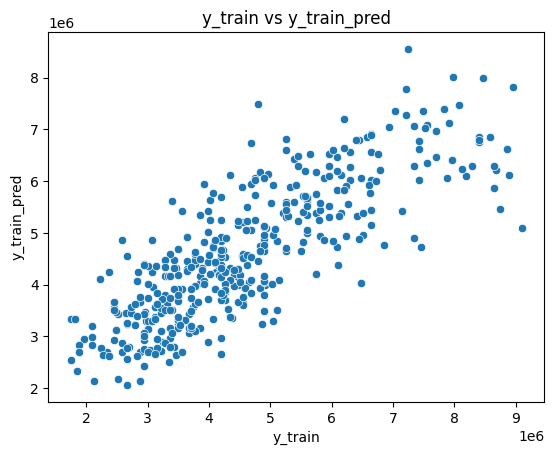

In [566]:
# plotting residuals
fig = plt.figure()
sns.scatterplot(x=y_train, y=y_train_pred)
plt.title('y_train vs y_train_pred')
plt.xlabel('y_train')
plt.ylabel('y_train_pred')
plt.show()

<Figure size 640x480 with 0 Axes>

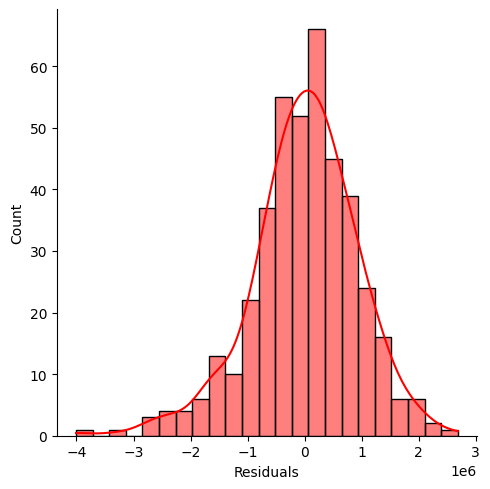

In [569]:
fig = plt.figure()
sns.displot(residuals, kde=True, fill=True, color='red')
plt.xlabel('Residuals')
plt.show()

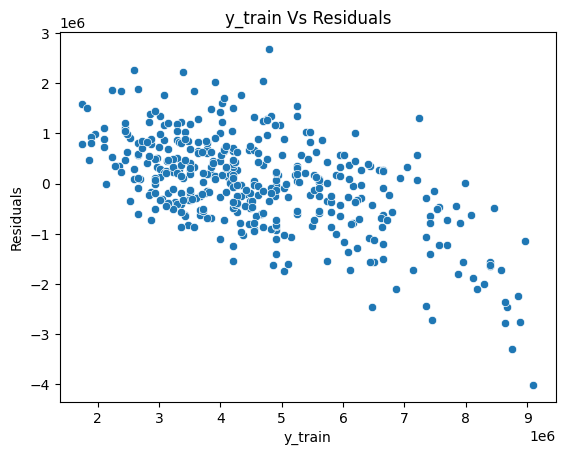

In [571]:
fig = plt.figure()

sns.scatterplot(x=y_train, y=residuals)
plt.xlabel('y_train')
plt.ylabel('Residuals')
plt.title("y_train Vs Residuals")
plt.show()

### Create Predictions and Evaluate Model

In [575]:
y_test_pred = lr_model.predict(x_test)
y_test_pred

array([4436843.19331783, 3202469.21973951, 4527309.53733413,
       4224210.46260361, 5222951.64339064, 7205673.8449711 ,
       5483653.3857011 , 2753317.39643603, 2999831.97442278,
       5378873.284515  , 3489340.71244579, 3849527.13328368,
       3272313.97744728, 6404796.98337471, 5772010.83452075,
       6572791.90148076, 4524980.06909937, 2280341.9260395 ,
       4097806.12001541, 4234036.13118481, 7351754.05453993,
       4738644.3628987 , 2349932.02041403, 3532252.29016393,
       3330690.1022496 , 4383844.53881942, 5409569.87996463,
       3732744.72780908, 4933631.50082444, 7311416.7222921 ,
       6114685.17166932, 3062200.16310055, 2851442.31754231,
       3377935.48141539, 2819208.43173153, 3763927.55325046,
       4604981.65871097, 4702772.00773412, 4007507.18095733,
       2241258.58807416, 2463022.90158745, 5641766.48603368,
       3540499.41967236, 3674106.40489567, 5491974.8487369 ,
       4897423.9226337 , 4015842.68382195, 6451976.70837439,
       5821539.69259525,

In [576]:
# Evaluating predictions
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
r2_score(y_test, y_test_pred)

0.6536406527058503

In [577]:
mean_absolute_error(y_test, y_test_pred)

665429.5951777752

In [578]:
mean_absolute_percentage_error(y_test, y_test_pred)

0.15977156118914204

In [579]:
# Less than 20% average percentage error is not a bad result on such a small dataset
# Results will improve if we get more data to train the model
# Some additional features, like distance from best school, shopping and entertainment options, age of the property etc.

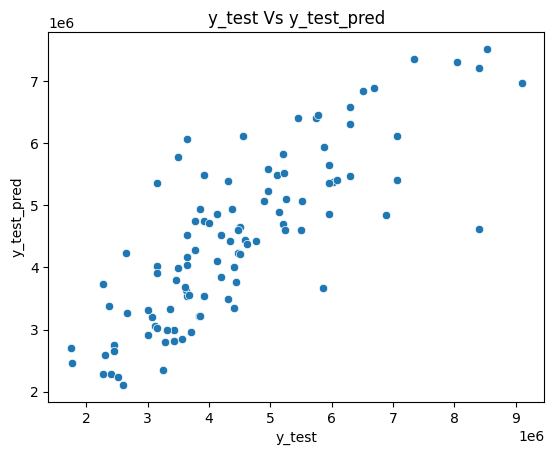

In [582]:
# Plotting y_test and y_test_pred to understand the spread
fig = plt.figure()
sns.scatterplot(x=y_test, y=y_test_pred)
plt.title('y_test Vs y_test_pred')
plt.xlabel('y_test')
plt.ylabel('y_test_pred')
plt.show()